In [1]:
import pandas as pd # 표(데이터프레임)을 다루는 도구 
import numpy as np # 수학 계산 도구
import matplotlib.pyplot as plt # 그래프 그리는 도구
import seaborn as sns # 예쁜 그래프 도구
import warnings
warnings.filterwarnings('ignore') #불필요한 경고 메시지 숨기기

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


In [2]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
train = pd.read_csv("train.csv") # 학습용 데이터
test  = pd.read_csv("test.csv") # 예측 대상 데이터 

train.shape, test.shape  # (1000, 26), (250, 25) 나오면 정상!

((1000, 26), (250, 25))

In [4]:
train.head()

,team_name,country_code,confederation,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,...,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
0,Poland,POL,UEFA,18,1675.2,5,4,1,0.520,1.11,...,256.0,26,10,6.5,47.3,76.8,0,6.2,0.61,1
1,Brazil,BRA,CONMEBOL,8,1831.2,7,2,1,0.690,2.31,...,1174.0,53,25,8.2,55.2,87.4,0,6.7,0.70,1
2,Netherlands,NED,UEFA,6,1769.3,6,2,2,0.585,1.85,...,741.0,49,12,7.2,56.3,88.4,0,8.0,0.61,1
3,Germany,DEU,UEFA,17,1663.4,7,1,2,0.584,1.40,...,593.0,43,16,8.1,57.5,80.6,0,6.2,0.55,0
4,Nigeria,NGA,CAF,28,1476.6,3,5,2,0.390,0.95,...,236.0,21,1,3.1,45.1,72.5,0,8.6,0.48,0


In [5]:
test.head()

,team_name,country_code,confederation,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,...,star_players_count,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score
0,Argentina,ARG,CONMEBOL,6,1784.8,6,2,2,0.747,2.18,...,5,1109.0,63,22,8.9,67.9,86.1,0,7.4,0.79
1,Ecuador,ECU,CONMEBOL,23,1669.3,6,4,0,0.482,1.55,...,2,386.0,38,11,5.6,54.0,77.3,0,6.7,0.75
2,Morocco,MAR,CAF,21,1714.0,4,5,1,0.582,1.40,...,3,375.0,25,14,5.3,53.7,83.9,0,7.2,0.41
3,China,CHN,AFC,35,1531.5,2,6,2,0.216,0.83,...,0,367.0,23,1,5.0,48.6,75.2,0,10.4,0.59
4,Croatia,CRO,UEFA,12,1697.9,7,2,1,0.606,1.96,...,4,461.0,50,17,5.7,58.7,88.8,0,6.0,0.59


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   team_name                 1000 non-null   object 
 1   country_code              1000 non-null   object 
 2   confederation             1000 non-null   object 
 3   fifa_rank                 1000 non-null   int64  
 4   fifa_points               1000 non-null   float64
 5   wins_last_10_matches      1000 non-null   int64  
 6   losses_last_10_matches    1000 non-null   int64  
 7   draws_last_10_matches     1000 non-null   int64  
 8   win_rate_last_year        1000 non-null   float64
 9   goals_scored_avg          1000 non-null   float64
 10  goals_conceded_avg        1000 non-null   float64
 11  clean_sheets_last_10      1000 non-null   int64  
 12  shots_per_game            1000 non-null   float64
 13  shots_on_target_ratio     1000 non-null   float64
 14  avg_playe

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   team_name                 250 non-null    object 
 1   country_code              250 non-null    object 
 2   confederation             250 non-null    object 
 3   fifa_rank                 250 non-null    int64  
 4   fifa_points               250 non-null    float64
 5   wins_last_10_matches      250 non-null    int64  
 6   losses_last_10_matches    250 non-null    int64  
 7   draws_last_10_matches     250 non-null    int64  
 8   win_rate_last_year        250 non-null    float64
 9   goals_scored_avg          250 non-null    float64
 10  goals_conceded_avg        250 non-null    float64
 11  clean_sheets_last_10      250 non-null    int64  
 12  shots_per_game            250 non-null    float64
 13  shots_on_target_ratio     250 non-null    float64
 14  avg_player

In [8]:
train.describe()

,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,goals_conceded_avg,clean_sheets_last_10,shots_per_game,...,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,22.603000,1657.906400,4.89900,3.360000,1.817000,0.51986,1.467460,1.185770,2.623000,12.197100,...,515.001000,37.262000,9.985000,5.813100,51.904300,81.173700,0.063000,7.07100,0.595830,0.47300
std,14.372681,148.913605,2.30176,1.909462,1.378917,0.16423,0.538391,0.427484,1.765216,3.464376,...,258.395738,12.076639,5.691148,1.979848,6.603785,6.038223,0.243085,2.72274,0.145756,0.49952
min,1.000000,1400.400000,1.00000,0.000000,0.000000,0.20100,0.500000,0.410000,0.000000,6.000000,...,200.000000,15.000000,1.000000,0.000000,40.100000,70.000000,0.000000,0.50000,0.250000,0.00000
25%,9.000000,1541.525000,3.00000,2.000000,1.000000,0.40100,1.070000,0.880000,1.000000,9.500000,...,308.000000,28.000000,6.000000,4.400000,46.800000,76.375000,0.000000,5.70000,0.490000,0.00000
50%,21.000000,1651.000000,5.00000,3.000000,2.000000,0.52750,1.410000,1.120000,2.000000,12.000000,...,436.000000,37.000000,9.000000,5.750000,51.500000,80.700000,0.000000,7.30000,0.600000,0.00000
75%,34.000000,1768.975000,7.00000,5.000000,3.000000,0.65550,1.860000,1.450000,4.000000,14.900000,...,706.250000,45.000000,14.000000,7.300000,56.500000,85.900000,0.000000,8.50000,0.700000,1.00000
max,50.000000,1999.500000,9.00000,7.000000,5.000000,0.85000,2.800000,2.200000,7.000000,20.000000,...,1198.000000,65.000000,25.000000,10.000000,67.900000,94.900000,1.000000,14.70000,0.950000,1.00000


In [9]:
train['winner'].value_counts()

winner
0    527
1    473
Name: count, dtype: int64

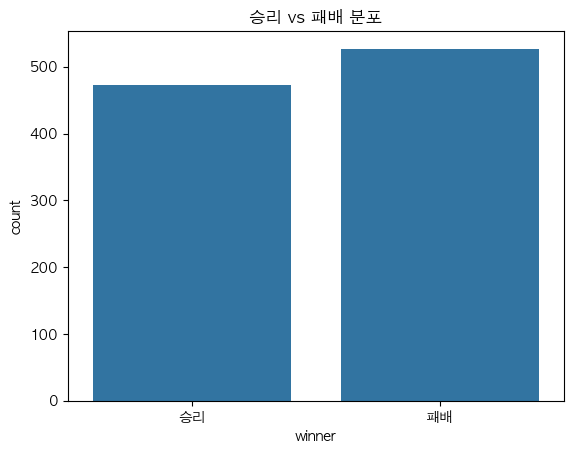

In [10]:
sns.countplot(data = train, x = 'winner', order=[1, 0])
plt.title('승리 vs 패배 분포')
plt.xticks([0, 1], ['승리', '패배']);

Text(0.5, 1.0, '승리 vs 패배 비율')

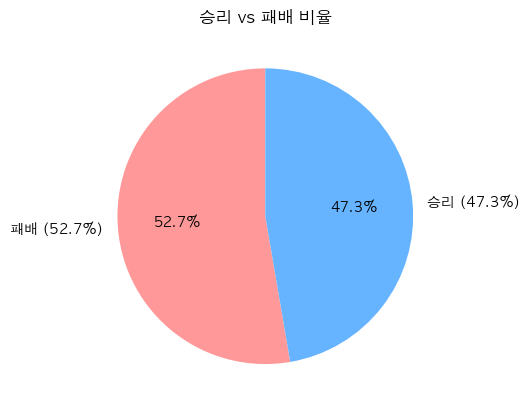

In [11]:
labels = ['패배 (52.7%)', '승리 (47.3%)']
sizes  = [527, 473]
colors = ['#ff9999', '#66b3ff']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('승리 vs 패배 비율')

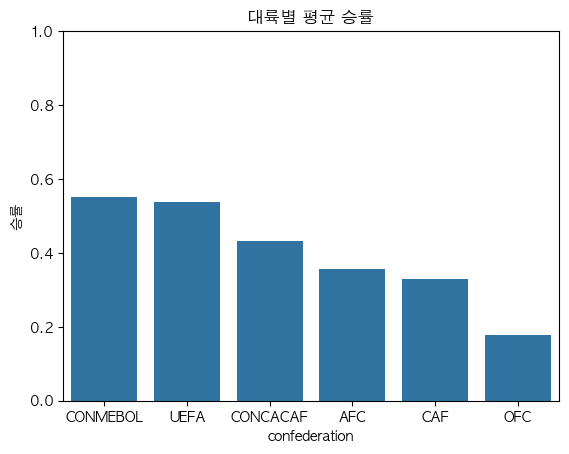

In [12]:
conf_winrate = train.groupby('confederation')['winner'].mean().sort_values(ascending=False)

sns.barplot(x=conf_winrate.index, y=conf_winrate.values)
plt.title('대륙별 평균 승률')
plt.ylabel('승률')
plt.ylim(0, 1);

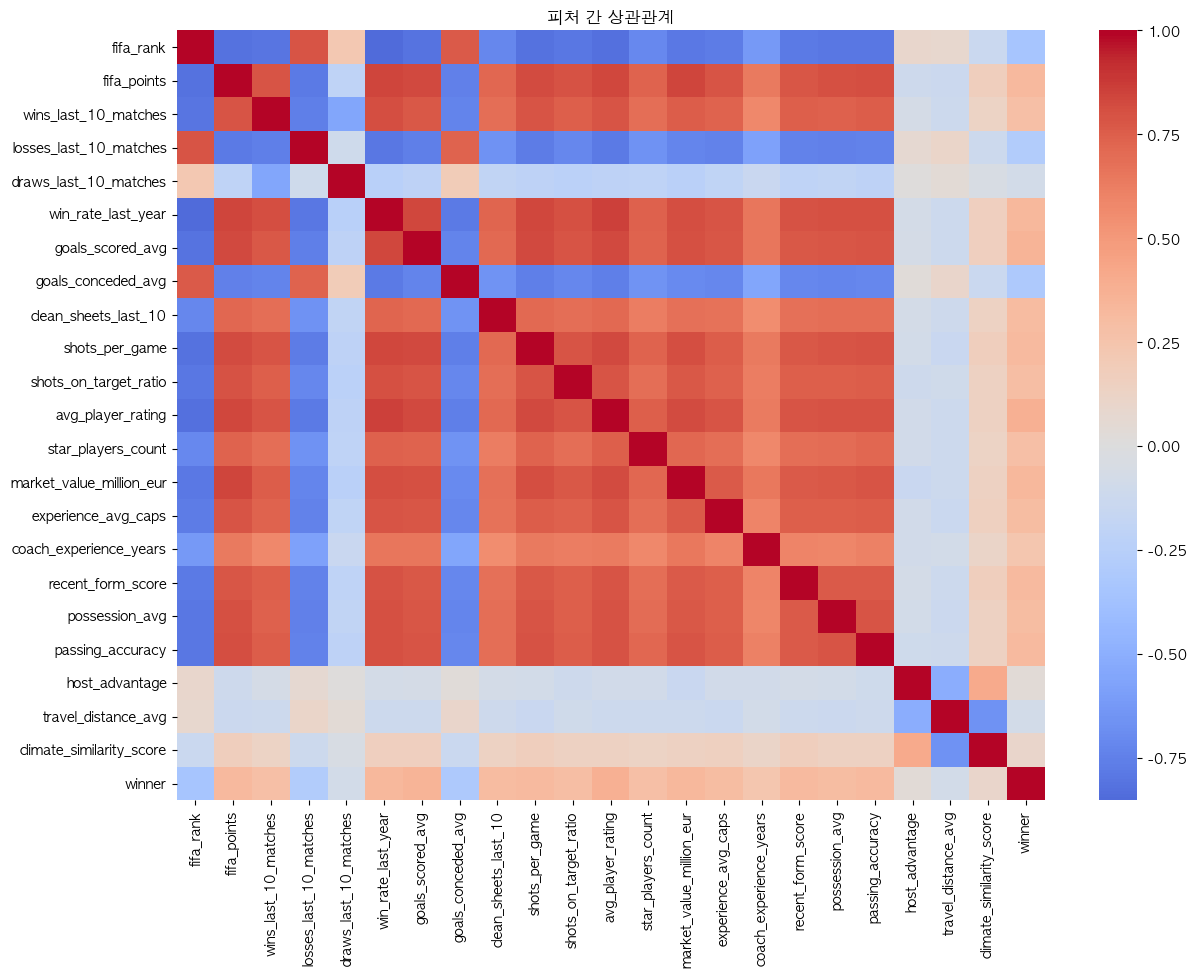

In [13]:
numeric_cols = train.select_dtypes(include = 'number').columns

plt.figure(figsize = (14, 10))
sns.heatmap(train[numeric_cols].corr(), annot = False, cmap = 'coolwarm', center = 0)
plt.title('피처 간 상관관계');

In [14]:
train[numeric_cols].corr()['winner'] \
									 .abs() \
									 .sort_values(ascending=False) \
									 .head(10)

winner                      1.000000
avg_player_rating           0.375663
goals_scored_avg            0.354978
fifa_rank                   0.351663
win_rate_last_year          0.333103
market_value_million_eur    0.328268
fifa_points                 0.326679
recent_form_score           0.319543
passing_accuracy            0.319308
shots_per_game              0.314711
Name: winner, dtype: float64

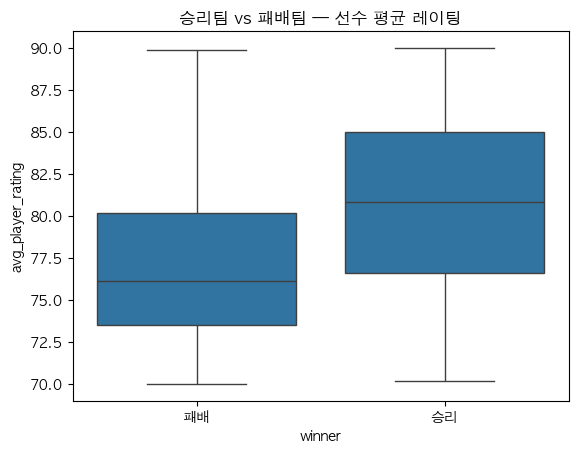

In [15]:
sns.boxplot(data = train, x = 'winner', y = 'avg_player_rating')
plt.xticks([0, 1], ['패배', '승리'])
plt.title('승리팀 vs 패배팀 — 선수 평균 레이팅');

Text(0.5, 1.0, '승리팀 vs 패배팀 — 최근 1년 승률')

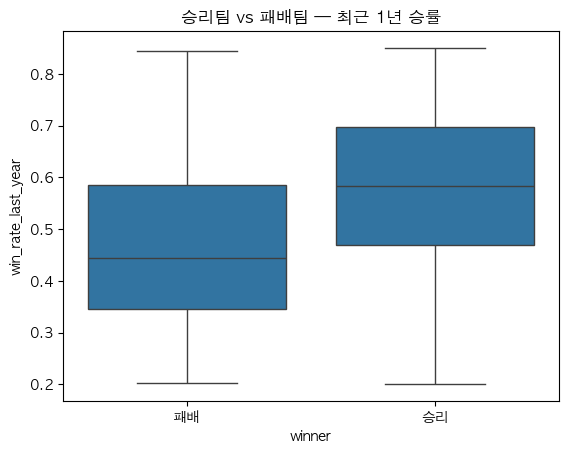

In [16]:
sns.boxplot(data=train, x='winner', y='win_rate_last_year')
plt.xticks([0, 1], ['패배', '승리'])
plt.title('승리팀 vs 패배팀 — 최근 1년 승률')

Text(0.5, 1.0, '승리팀 vs 패배팀 — 평균 득점')

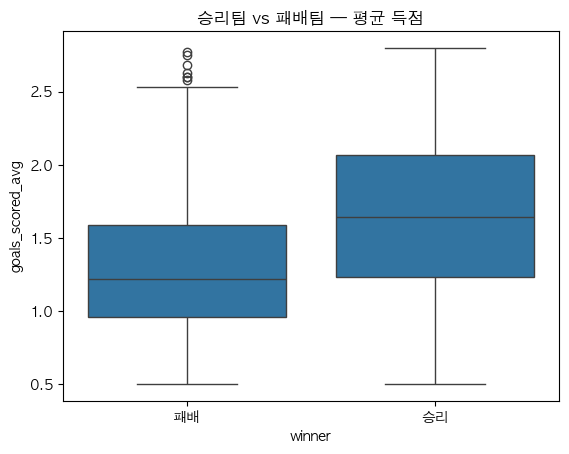

In [17]:
sns.boxplot(data=train, x='winner', y='goals_scored_avg')
plt.xticks([0, 1], ['패배', '승리'])
plt.title('승리팀 vs 패배팀 — 평균 득점')

Text(0.5, 1.0, '승리팀 vs 패배팀 — 평균 실점')

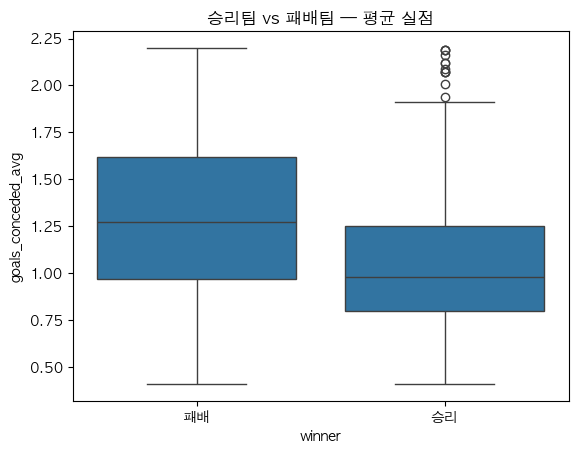

In [18]:
sns.boxplot(data=train, x='winner', y='goals_conceded_avg')
plt.xticks([0, 1], ['패배', '승리'])
plt.title('승리팀 vs 패배팀 — 평균 실점')

Text(0.5, 1.0, '승리팀 vs 패배팀 — FIFA 포인트')

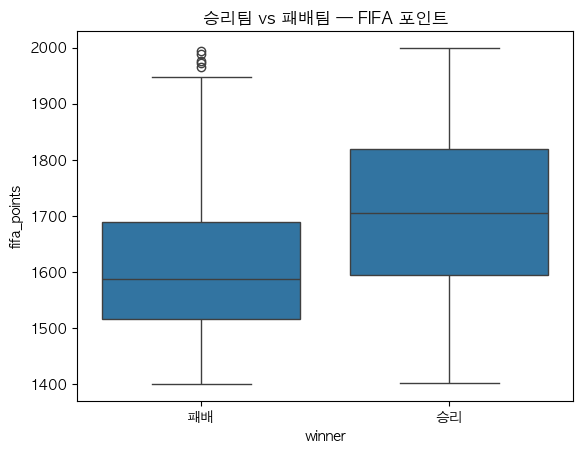

In [19]:
sns.boxplot(data=train, x='winner', y='fifa_points')
plt.xticks([0, 1], ['패배', '승리'])
plt.title('승리팀 vs 패배팀 — FIFA 포인트')

Text(0.5, 1.0, '승리팀 vs 패배팀 — 최근 폼 점수')

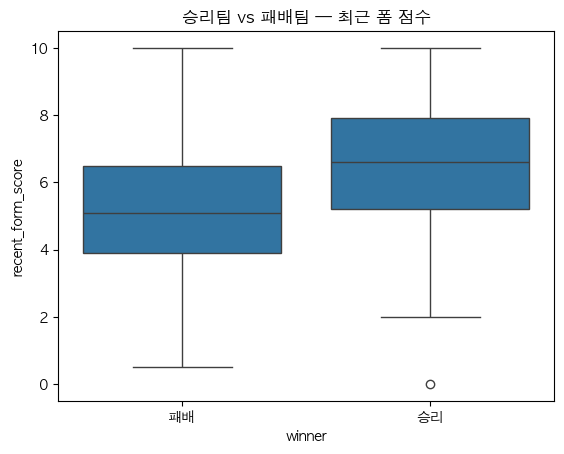

In [20]:
sns.boxplot(data=train, x='winner', y='recent_form_score')
plt.xticks([0, 1], ['패배', '승리'])
plt.title('승리팀 vs 패배팀 — 최근 폼 점수')

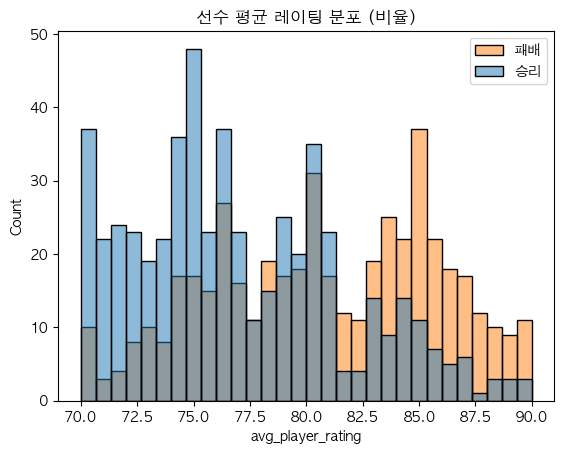

In [21]:
sns.histplot(data=train, x='avg_player_rating', hue='winner', bins=30)
plt.title('선수 평균 레이팅 분포 (비율)')
plt.legend(['패배', '승리'])

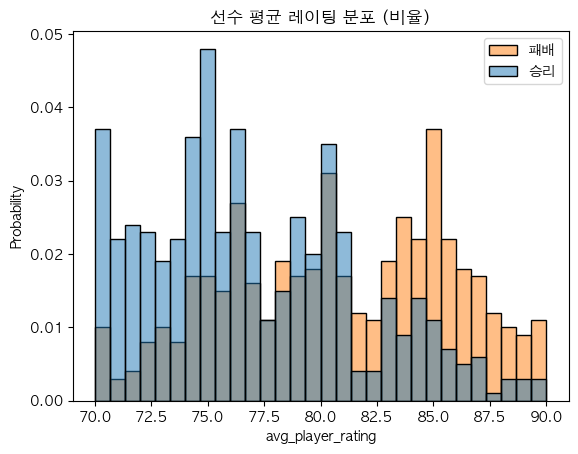

In [22]:
sns.histplot(data=train, x='avg_player_rating', hue='winner', bins=30, stat='probability')
plt.title('선수 평균 레이팅 분포 (비율)')
plt.legend(['패배', '승리']);

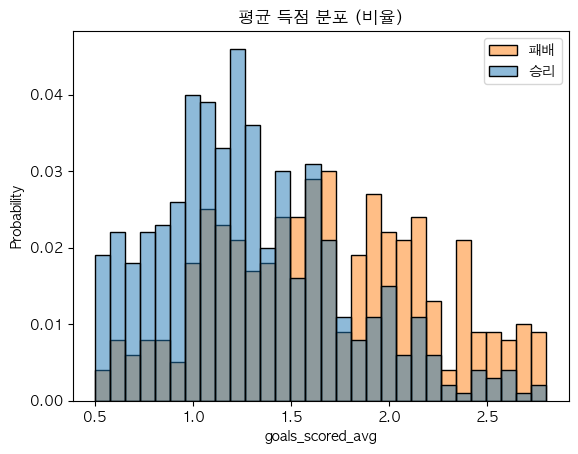

In [23]:
sns.histplot(data=train, x='goals_scored_avg', hue='winner', bins=30, stat='probability')
plt.title('평균 득점 분포 (비율)')
plt.legend(['패배', '승리']);

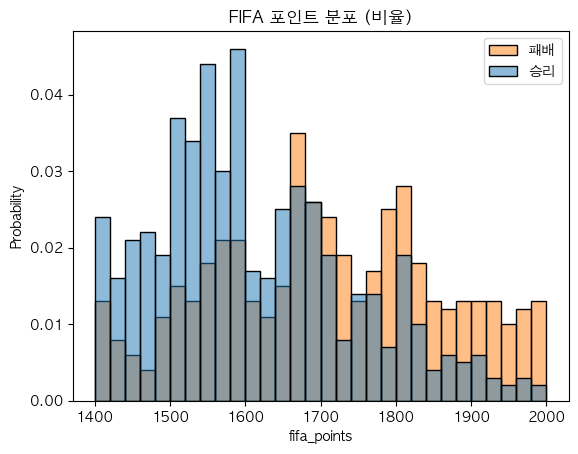

In [24]:
sns.histplot(data=train, x='fifa_points', hue='winner', bins=30, stat='probability')
plt.title('FIFA 포인트 분포 (비율)')
plt.legend(['패배', '승리'])

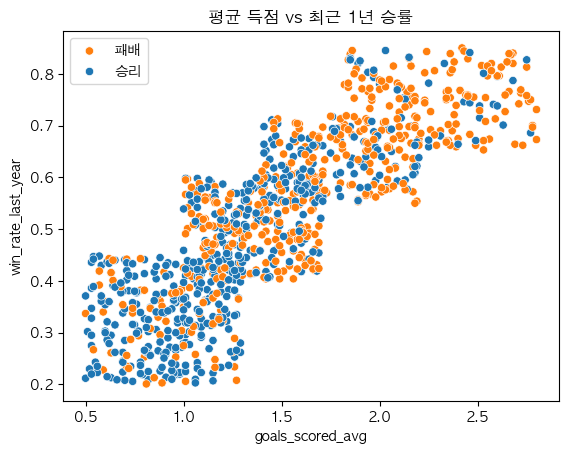

In [25]:
sns.scatterplot(data=train, x='goals_scored_avg', y='win_rate_last_year', hue='winner')
plt.title('평균 득점 vs 최근 1년 승률')
plt.legend(['패배', '승리'])

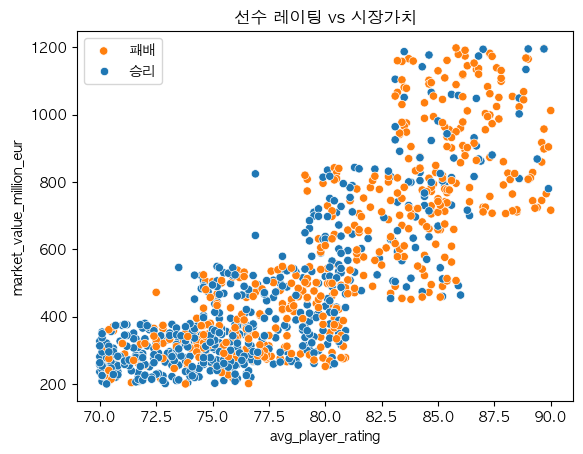

In [26]:
sns.scatterplot(data=train, x='avg_player_rating', y='market_value_million_eur', hue='winner')
plt.title('선수 레이팅 vs 시장가치')
plt.legend(['패배', '승리']);

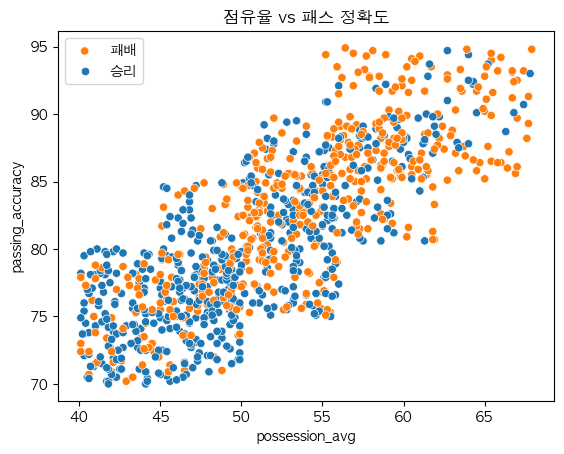

In [27]:
sns.scatterplot(data=train, x='possession_avg', y='passing_accuracy', hue='winner')
plt.title('점유율 vs 패스 정확도')
plt.legend(['패배', '승리']);

In [28]:
corr_matrix = train[numeric_cols].corr().abs()
corr_matrix

,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,goals_conceded_avg,clean_sheets_last_10,shots_per_game,...,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
fifa_rank,1.000000,0.822731,0.804405,0.791487,0.224828,0.852583,0.810613,0.766143,0.718812,0.817980,...,0.791315,0.778304,0.622955,0.785425,0.795708,0.798617,0.091113,0.085484,0.134721,0.351663
fifa_points,0.822731,1.000000,0.785437,0.783951,0.204124,0.846324,0.831359,0.748693,0.724938,0.822339,...,0.842262,0.790047,0.639947,0.780496,0.805416,0.818794,0.108878,0.125101,0.166555,0.326679
wins_last_10_matches,0.804405,0.785437,1.000000,0.761751,0.559324,0.817697,0.772704,0.734478,0.684872,0.786889,...,0.758571,0.739383,0.579105,0.751821,0.742867,0.757156,0.065545,0.115485,0.131575,0.284490
losses_last_10_matches,0.791487,0.783951,0.761751,1.000000,0.100412,0.795033,0.764458,0.734521,0.670662,0.778584,...,0.726279,0.736878,0.582397,0.739943,0.747678,0.741966,0.071857,0.108445,0.119368,0.282601
draws_last_10_matches,0.224828,0.204124,0.559324,0.100412,1.000000,0.240113,0.210145,0.193192,0.193692,0.214096,...,0.237356,0.195122,0.146273,0.207311,0.188053,0.214984,0.010539,0.039511,0.046931,0.082023
win_rate_last_year,0.852583,0.846324,0.817697,0.795033,0.240113,1.000000,0.839618,0.781770,0.730212,0.839120,...,0.812868,0.795976,0.653488,0.799934,0.807828,0.809125,0.072945,0.121005,0.159439,0.333103
goals_scored_avg,0.810613,0.831359,0.772704,0.764458,0.210145,0.839618,1.000000,0.735657,0.712875,0.832059,...,0.810401,0.781389,0.654199,0.770550,0.782866,0.794075,0.068760,0.119893,0.155457,0.354978
goals_conceded_avg,0.766143,0.748693,0.734478,0.734521,0.193192,0.781770,0.735657,1.000000,0.653402,0.753453,...,0.703617,0.719652,0.559764,0.716821,0.723454,0.720701,0.029250,0.100598,0.138175,0.308074
clean_sheets_last_10,0.718812,0.724938,0.684872,0.670662,0.193692,0.730212,0.712875,0.653402,1.000000,0.710890,...,0.680037,0.670192,0.556528,0.675707,0.687841,0.685886,0.072898,0.112203,0.138028,0.309147
shots_per_game,0.817980,0.822339,0.786889,0.778584,0.214096,0.839120,0.832059,0.753453,0.710890,1.000000,...,0.813106,0.757848,0.640140,0.774991,0.786868,0.801331,0.083582,0.143717,0.165745,0.314711


In [29]:
corr_matrix = train[numeric_cols].corr().abs()

high_corr = corr_matrix[corr_matrix >= 0.8]
high_corr = high_corr[high_corr < 1.0]
high_corr = high_corr.stack().reset_index()
high_corr = high_corr.rename(columns = {'level_0': '피처1', 'level_1': '피처2', 0: '상관계수'})
high_corr.sort_values('상관계수', ascending=False)

,피처1,피처2,상관계수
23,win_rate_last_year,avg_player_rating,0.858160
44,avg_player_rating,win_rate_last_year,0.858160
2,fifa_rank,win_rate_last_year,0.852583
17,win_rate_last_year,fifa_rank,0.852583
7,fifa_points,win_rate_last_year,0.846324
18,win_rate_last_year,fifa_points,0.846324
12,fifa_points,market_value_million_eur,0.842262
49,market_value_million_eur,fifa_points,0.842262
29,goals_scored_avg,win_rate_last_year,0.839618
20,win_rate_last_year,goals_scored_avg,0.839618


In [30]:
# 필요없는 컬럼 직접 제거
drop_cols = ['team_name', 'country_code', 'confederation', 'winner']
X = train.drop(columns=drop_cols).fillna(0)
y = train['winner']
X_test = test.drop(columns=['team_name', 'country_code', 'confederation']).fillna(0)

X.shape, y.shape, X_test.shape
# (1000, 22), (1000,), (250, 22) 나오면 정상!

((1000, 22), (1000,), (250, 22))

In [33]:
X['strength_index'] = X['fifa_points'] + X['recent_form_score'] * 50 + X['avg_player_rating'] * 10
X_test['strength_index'] = X_test['fifa_points'] + X_test['recent_form_score'] * 50 + X_test['avg_player_rating'] * 10
X['strength_index'].head()

0    2750.2
1    3103.2
2    2982.3
3    2900.4
4    2339.6
Name: strength_index, dtype: float64

In [34]:
X['goal_efficiency'] = X['goals_scored_avg'] / X['goals_conceded_avg'].clip(lower = 0.1)
X_test['goal_efficiency'] = X_test['goals_scored_avg'] / X_test['goals_conceded_avg'].clip(lower=0.1)

X['goal_efficiency'].head()

0    1.219780
1    3.039474
2    2.983871
3    1.284404
4    0.482234
Name: goal_efficiency, dtype: float64

In [35]:
X['attack_potency'] = X['shots_per_game'] * X['shots_on_target_ratio'] * X['goals_scored_avg']
X_test['attack_potency'] = X_test['shots_per_game'] * X_test['shots_on_target_ratio'] * X_test['goals_scored_avg']

X['attack_potency'].head()

0     4.264620
1    22.264704
2    13.883880
3     9.893520
4     1.878910
Name: attack_potency, dtype: float64

In [36]:
X['defensive_solidity'] = X['clean_sheets_last_10'] / (X['goals_conceded_avg'] + 0.5)
X_test['defensive_solidity'] = X_test['clean_sheets_last_10'] / (X_test['goals_conceded_avg'] + 0.5)

X['defensive_solidity'].head()

0    2.127660
1    3.968254
2    2.678571
3    1.257862
4    0.809717
Name: defensive_solidity, dtype: float64

In [37]:
X['squad_quality'] = (X['avg_player_rating'] * 0.4 +
                      (X['market_value_million_eur'] / 1200) * 100 * 0.3 +
                      (X['experience_avg_caps'] / 65) * 100 * 0.3)

X_test['squad_quality'] = (X_test['avg_player_rating'] * 0.4 +
                           (X_test['market_value_million_eur'] / 1200) * 100 * 0.3 +
                           (X_test['experience_avg_caps'] / 65) * 100 * 0.3)

X['squad_quality'].head()

0    48.400000
1    88.291538
2    75.260385
3    67.951154
4    43.912308
Name: squad_quality, dtype: float64

In [38]:
X['form_consistency'] = X['win_rate_last_year'] * X['recent_form_score']
X_test['form_consistency'] = X_test['win_rate_last_year'] * X_test['recent_form_score']

X['form_consistency'].head()

0    3.3800
1    5.6580
2    4.2120
3    4.7304
4    1.2090
Name: form_consistency, dtype: float64

In [39]:
X['possession_dominance'] = X['possession_avg'] * X['passing_accuracy'] / 100
X_test['possession_dominance'] = X_test['possession_avg'] * X_test['passing_accuracy'] / 100

X['possession_dominance'].head()

0    36.3264
1    48.2448
2    49.7692
3    46.3450
4    32.6975
Name: possession_dominance, dtype: float64

In [40]:
X['star_power'] = X['star_players_count'] * X['market_value_million_eur']
X_test['star_power'] = X_test['star_players_count'] * X_test['market_value_million_eur']

X['star_power'].head()

0     768.0
1    4696.0
2    2223.0
3    1779.0
4       0.0
Name: star_power, dtype: float64

In [41]:
X['contextual_advantage'] = (X['host_advantage'] * 10 +
                              X['climate_similarity_score'] * 5 -
                              X['travel_distance_avg'] * 0.5)

X_test['contextual_advantage'] = (X_test['host_advantage'] * 10 +
                                   X_test['climate_similarity_score'] * 5 -
                                   X_test['travel_distance_avg'] * 0.5)

X['contextual_advantage'].head()

0   -0.05
1    0.15
2   -0.95
3   -0.35
4   -1.90
Name: contextual_advantage, dtype: float64

In [42]:
X.shape

(1000, 31)

In [43]:
X

,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,goals_conceded_avg,clean_sheets_last_10,shots_per_game,...,climate_similarity_score,strength_index,goal_efficiency,attack_potency,defensive_solidity,squad_quality,form_consistency,possession_dominance,star_power,contextual_advantage
0,18,1675.2,5,4,1,0.520,1.11,0.91,3,11.3,...,0.61,2750.2,1.219780,4.264620,2.127660,48.400000,3.3800,36.3264,768.0,-0.05
1,8,1831.2,7,2,1,0.690,2.31,0.76,5,19.2,...,0.70,3103.2,3.039474,22.264704,3.968254,88.291538,5.6580,48.2448,4696.0,0.15
2,6,1769.3,6,2,2,0.585,1.85,0.62,3,15.9,...,0.61,2982.3,2.983871,13.883880,2.678571,75.260385,4.2120,49.7692,2223.0,-0.95
3,17,1663.4,7,1,2,0.584,1.40,1.09,2,15.6,...,0.55,2900.4,1.284404,9.893520,1.257862,67.951154,4.7304,46.3450,1779.0,-0.35
4,28,1476.6,3,5,2,0.390,0.95,1.97,2,6.2,...,0.48,2339.6,0.482234,1.878910,0.809717,43.912308,1.2090,32.6975,0.0,-1.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,1973.5,8,0,2,0.708,1.96,0.49,3,14.7,...,0.61,3276.5,4.000000,13.512828,3.030303,89.039231,6.5136,57.0570,5710.0,-0.75
996,5,1675.4,6,3,1,0.592,1.67,1.18,4,13.2,...,0.74,2869.4,1.415254,8.200368,2.380952,68.931154,4.3216,41.4504,1911.0,1.65
997,30,1713.1,5,2,3,0.575,1.60,1.41,3,12.2,...,0.86,2843.1,1.134752,5.992640,1.570681,54.194231,3.9100,42.3150,939.0,13.70
998,48,1433.8,1,6,3,0.365,1.00,1.62,0,10.0,...,0.42,2310.8,0.617284,2.380000,0.000000,49.168462,1.2410,36.1982,374.0,-1.50


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size = 0.2,      # 20%를 검증용으로
    random_state = 42,    # 매번 같은 방식으로 나누기
    stratify = y          # 승/패(타겟변수) 비율 유지하면서 나누기, 없으면 검증 데이터에 승리만 몰릴 수도 있다.
)

X_train.shape, X_val.shape
# (800, 31), (200, 31)

((800, 31), (200, 31))

In [45]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

In [46]:
gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

gb.fit(X_train, y_train)

'GradientBoosting 학습 완료!'

'GradientBoosting 학습 완료!'

In [47]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

'RandomForest 학습 완료!'

'RandomForest 학습 완료!'

In [48]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

'LogisticRegression 학습 완료!'

'LogisticRegression 학습 완료!'

In [49]:
# 예측
gb_pred = gb.predict(X_val)
rf_pred = rf.predict(X_val)
lr_pred = lr.predict(X_val_s)

# 확률 예측
gb_proba = gb.predict_proba(X_val)[:, 1]
rf_proba = rf.predict_proba(X_val)[:, 1]
lr_proba = lr.predict_proba(X_val_s)[:, 1]

# 성능 비교표
pd.DataFrame({
    '모델': ['GradientBoosting', 'RandomForest', 'LogisticRegression'],
    'Accuracy': [accuracy_score(y_val, gb_pred),
                 accuracy_score(y_val, rf_pred),
                 accuracy_score(y_val, lr_pred)],
    'AUC-ROC': [roc_auc_score(y_val, gb_proba),
                roc_auc_score(y_val, rf_proba),
                roc_auc_score(y_val, lr_proba)]
}).round(4)

,모델,Accuracy,AUC-ROC
0,GradientBoosting,0.565,0.6304
1,RandomForest,0.645,0.6707
2,LogisticRegression,0.655,0.6763


In [50]:
ens_proba = 0.5 * gb_proba + 0.35 * rf_proba + 0.15 * lr_proba
ens_pred  = (ens_proba >= 0.5).astype(int)

print(f"Ensemble Accuracy : {accuracy_score(y_val, ens_pred):.4f}")
print(f"Ensemble AUC-ROC  : {roc_auc_score(y_val, ens_proba):.4f}")

Ensemble Accuracy : 0.5800
Ensemble AUC-ROC  : 0.6414


In [51]:
ens_proba2 = 0.15 * gb_proba + 0.40 * rf_proba + 0.45 * lr_proba
ens_pred2  = (ens_proba2 >= 0.5).astype(int)

accuracy_score(y_val, ens_pred2), roc_auc_score(y_val, ens_proba2)

(0.645, 0.6679699248120301)

In [52]:
ens_proba = 0.5 * gb_proba + 0.35 * rf_proba + 0.15 * lr_proba
ens_pred  = (ens_proba >= 0.5).astype(int)

accuracy_score(y_val, ens_pred), roc_auc_score(y_val, ens_proba)

(0.58, 0.64140350877193)

In [53]:
ens_proba2 = 0.15 * gb_proba + 0.40 * rf_proba + 0.45 * lr_proba
ens_pred2  = (ens_proba2 >= 0.5).astype(int)

accuracy_score(y_val, ens_pred2), roc_auc_score(y_val, ens_proba2)

(0.645, 0.6679699248120301)

In [54]:
scaler_final = StandardScaler()
X_final      = scaler_final.fit_transform(X)
X_test_final = scaler_final.transform(X_test)

lr_final = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_final.fit(X_final, y)

'최종 모델 학습 완료!'

'최종 모델 학습 완료!'

In [55]:
test_proba = lr_final.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'id': range(len(test_proba)),
    'winner_probability': test_proba
})

submission.to_csv('submission.csv', index=False)
submission.head(10)

,id,winner_probability
0,0,0.799013
1,1,0.461839
2,2,0.600390
3,3,0.311728
4,4,0.633624
5,5,0.662425
6,6,0.747719
7,7,0.831340
8,8,0.284964
9,9,0.444293


In [56]:
test_with_pred = test.copy()
test_with_pred['winner_probability'] = test_proba

test_with_pred.groupby('team_name')['winner_probability'].mean().sort_values(ascending=False).head(10)

team_name
Argentina      0.783159
England        0.776078
Spain          0.775397
France         0.730764
Brazil         0.726087
Croatia        0.660847
Netherlands    0.635085
Portugal       0.627887
Colombia       0.625829
USA            0.625546
Name: winner_probability, dtype: float64